In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn
from sklearn.datasets import load_breast_cancer  # Standard dataset
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset shape:", X.shape)
print("Classes:", np.unique(y))

Dataset shape: (569, 30)
Classes: [0 1]


In [3]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
# Feature Scaling (Important for LR & KNN)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

## Training & Evaluation of Classifiers

In [6]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall: {recall_score(y_test, y_pred):.3f}")
    print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
    
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": auc
    }


=== Logistic Regression ===
Accuracy: 0.982
Precision: 0.986
Recall: 0.986
F1-score: 0.986


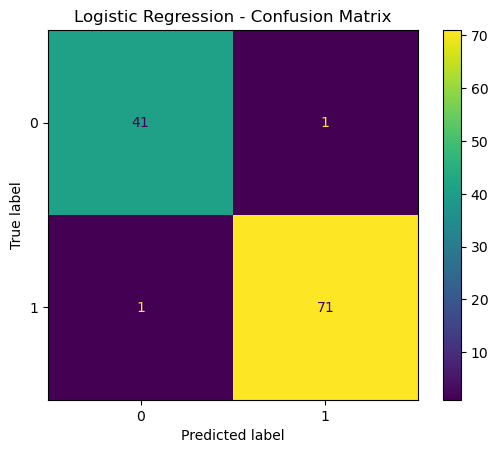

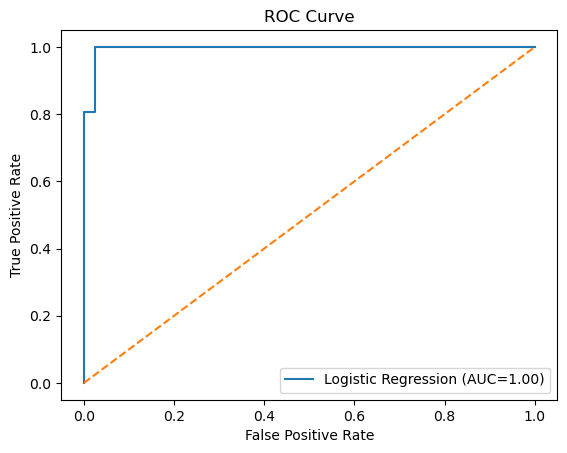


=== KNN (k=5) ===
Accuracy: 0.956
Precision: 0.959
Recall: 0.972
F1-score: 0.966


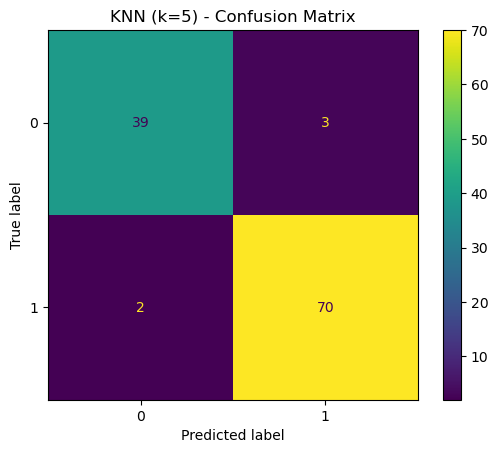

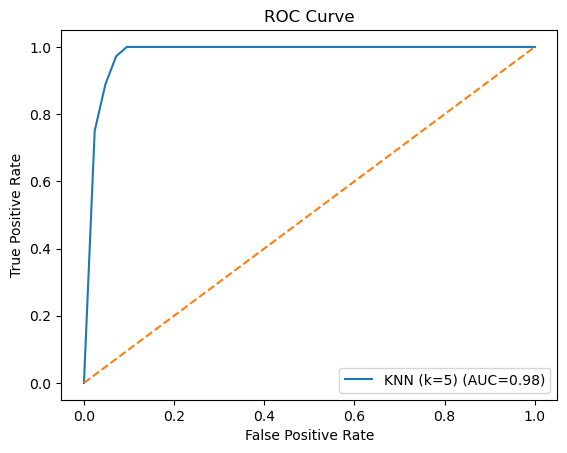


=== Decision Tree ===
Accuracy: 0.912
Precision: 0.956
Recall: 0.903
F1-score: 0.929


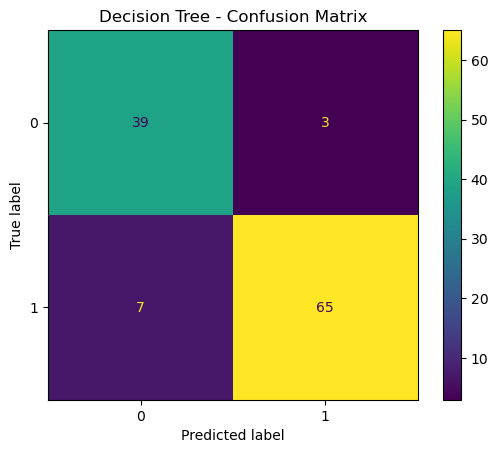

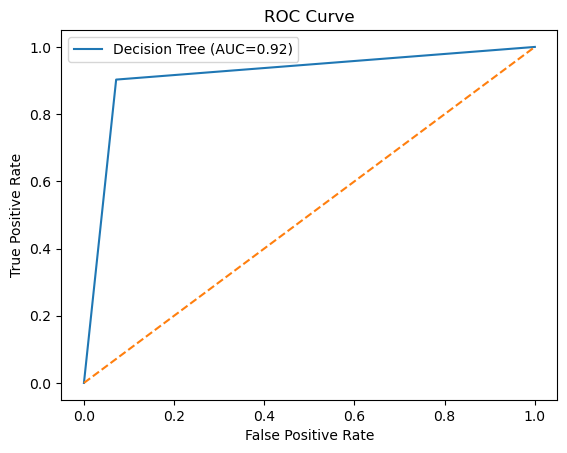


=== Random Forest ===
Accuracy: 0.956
Precision: 0.959
Recall: 0.972
F1-score: 0.966


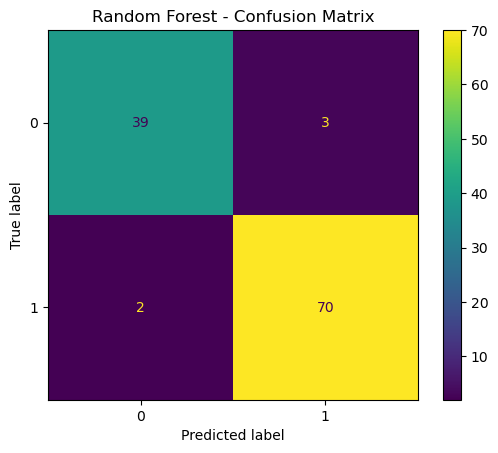

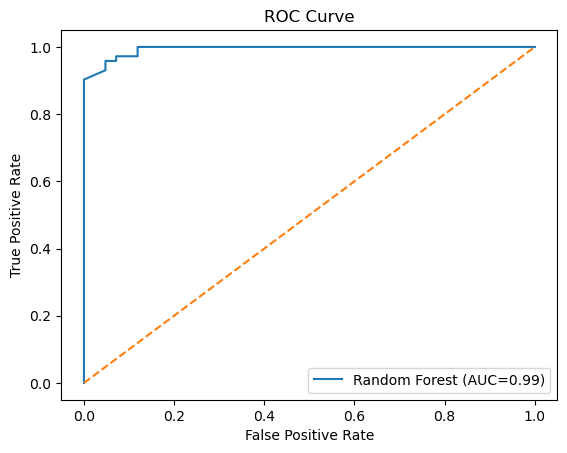

In [7]:
# Run Models
results = []

# Logistic Regression & KNN use scaled data
results.append(evaluate_model(
    "Logistic Regression",
    models["Logistic Regression"],
    X_train_scaled, X_test_scaled, y_train, y_test
))

results.append(evaluate_model(
    "KNN (k=5)",
    models["KNN (k=5)"],
    X_train_scaled, X_test_scaled, y_train, y_test
))

# Tree models use raw data
results.append(evaluate_model(
    "Decision Tree",
    models["Decision Tree"],
    X_train, X_test, y_train, y_test
))

results.append(evaluate_model(
    "Random Forest",
    models["Random Forest"],
    X_train, X_test, y_train, y_test
))

In [8]:
# Compare Models
results_df = pd.DataFrame(results)
results_df.sort_values(by="F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,KNN (k=5),0.956140,0.958904,0.972222,0.965517,0.978836
3,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993717
2,Decision Tree,0.912281,0.955882,0.902778,0.928571,0.915675


In [9]:
# Cross-Validation (Better Evaluation)
for name, model in models.items():
    if name in ["Logistic Regression", "KNN (k=5)"]:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    
    print(f"{name} CV F1: {scores.mean():.3f} ± {scores.std():.3f}")

Logistic Regression CV F1: 0.984 ± 0.010
KNN (k=5) CV F1: 0.974 ± 0.016
Decision Tree CV F1: 0.928 ± 0.015
Random Forest CV F1: 0.963 ± 0.018


## Hyperparameter Tuning Example (KNN)

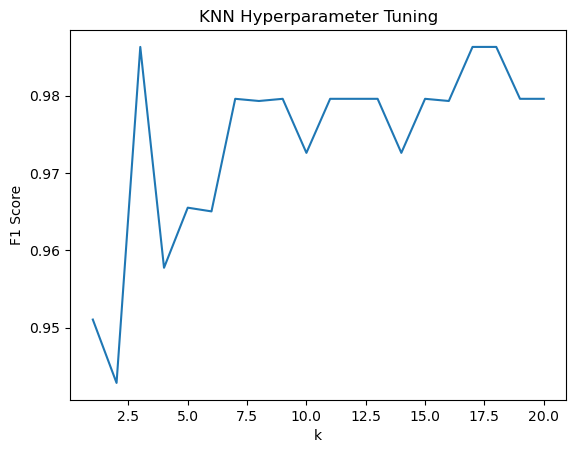

In [10]:
k_values = range(1, 21)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    scores.append(f1_score(y_test, y_pred))

plt.plot(k_values, scores)
plt.xlabel("k")
plt.ylabel("F1 Score")
plt.title("KNN Hyperparameter Tuning")
plt.show()